# Feature / Relationship Analysis — Bloomy Knowledge Tracing

Input: `data/processed/modeling_dataset.parquet`, built by `scripts/build_modeling_dataset.py` per the rules in `docs/data_quality_and_leakage.md`. This notebook asks a different question than `notebooks/eda.ipynb`: not "is the raw data trustworthy" but "do the engineered features actually predict `target_correct`, and are any of them redundant with each other?"

**All analysis below uses `split == "train"` only** — computing relationships on the full dataset (including `split == "test"`) would mean feature/model decisions get made after implicitly seeing the held-out set. Test stays untouched until final evaluation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

NUMERIC_COLS = [
    "n_prior_attempts", "prior_correct_count", "prior_correct_rate",
    "prior_hint_count_mean", "prior_attempt_count_mean",
    "prior_ms_first_response_mean", "prior_overlap_time_mean",
    "prior_hint_used_rate",
]

df = pd.read_parquet("../data/processed/modeling_dataset.parquet")
print("full shape:", df.shape)

train = df[df["split"] == "train"].copy()
print("train shape:", train.shape)

full shape: (417216, 17)
train shape: (383613, 17)


## 1. Correlation matrix — feature-feature and feature-target

Pearson correlation is valid between a continuous feature and a binary target (it reduces to point-biserial correlation), so `target_correct` is included directly in the matrix.

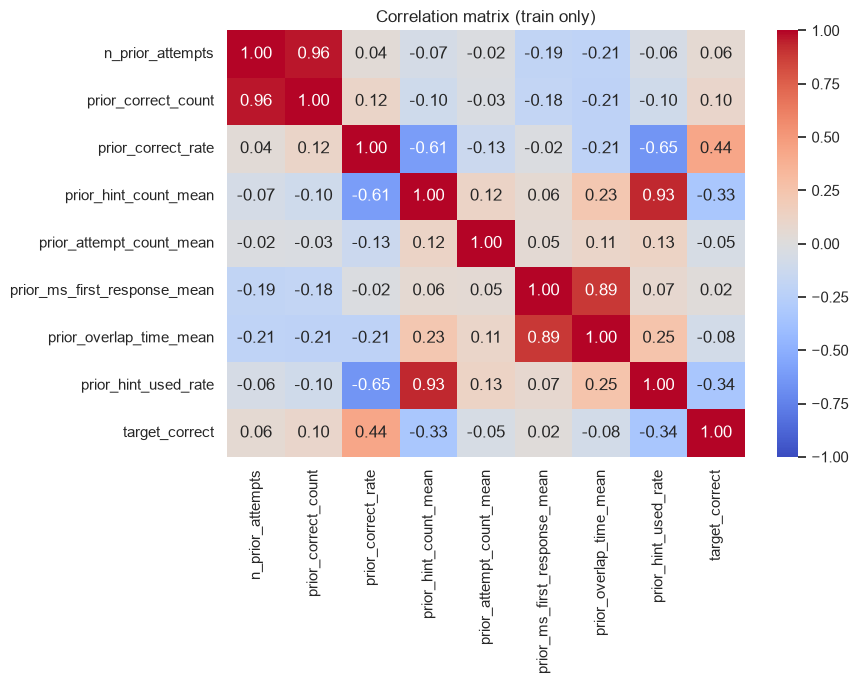

target_correct                  1.000000
prior_correct_rate              0.436543
prior_correct_count             0.096764
n_prior_attempts                0.056250
prior_ms_first_response_mean    0.018589
prior_attempt_count_mean       -0.054527
prior_overlap_time_mean        -0.080382
prior_hint_count_mean          -0.331357
prior_hint_used_rate           -0.337589
Name: target_correct, dtype: float64


In [3]:
corr = train[NUMERIC_COLS + ["target_correct"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (train only)")
plt.tight_layout()
plt.show()

print(corr["target_correct"].sort_values(ascending=False))

**Interpretation.** Correlation with `target_correct`, ranked by magnitude:

| feature | r |
|---|---|
| `prior_correct_rate` | **+0.437** |
| `prior_hint_used_rate` | -0.338 |
| `prior_hint_count_mean` | -0.331 |
| `prior_correct_count` | +0.097 |
| `prior_overlap_time_mean` | -0.080 |
| `prior_attempt_count_mean` | -0.055 |
| `n_prior_attempts` | +0.056 |
| `prior_ms_first_response_mean` | +0.019 |

`prior_correct_rate` is by far the strongest single signal — makes sense for a KT baseline (past performance on a skill predicts near-future performance on it). The two hint-usage features are the next strongest, both negative (more hint reliance historically → lower probability of correctness now), which is intuitive and gives two independent-looking confirmations of the same underlying "struggling" signal. `prior_ms_first_response_mean` is essentially uncorrelated (0.019) — a weak candidate for dropping. Two features that look weak individually here (`n_prior_attempts`, `prior_correct_count`) turn out to matter for a different reason — see the VIF check next.

## 2. Multicollinearity — VIF

A correlation heatmap only catches pairwise linear relationships. Variance Inflation Factor catches a feature being a linear combination of *several* others, which a pairwise heatmap can miss entirely.

In [4]:
X = train[NUMERIC_COLS].dropna()
X_const = add_constant(X)
vif = pd.Series(
    [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
    index=X_const.columns,
).drop("const")
print(vif.sort_values(ascending=False))

prior_correct_count             15.392533
n_prior_attempts                15.279444
prior_hint_used_rate             8.363356
prior_hint_count_mean            7.593167
prior_overlap_time_mean          6.134252
prior_ms_first_response_mean     5.709707
prior_correct_rate               1.982031
prior_attempt_count_mean         1.028878
dtype: float64


**Interpretation — this is the most actionable finding in this notebook.**

- `prior_correct_count` (VIF 15.39) and `n_prior_attempts` (VIF 15.28) are both far past the usual VIF>10 concern threshold. This is mechanical, not surprising once named: `prior_correct_rate = prior_correct_count / n_prior_attempts`, so keeping all three in a model means one is a deterministic function of the other two — classic multicollinearity, invisible in a pairwise correlation heatmap (neither pair individually looks alarming there) but obvious in VIF. **Recommendation: drop `prior_correct_count` from the feature set** — it carries no information beyond what `prior_correct_rate` (the normalized, more predictive version) and `n_prior_attempts` (a legitimate independent "how much history exists" signal) already capture together.
- `prior_hint_used_rate` (8.36) and `prior_hint_count_mean` (7.59) sit in a moderate-concern band — expected, since one is a coarsened version of the other (rate of *any* hint use vs. average hint *count*). Worth picking one, not both, once a model is chosen.
- `prior_overlap_time_mean` (6.13) and `prior_ms_first_response_mean` (5.71) also sit moderately high — confirms the raw-level redundancy flagged in `eda.ipynb`/`docs/data_quality_and_leakage.md` (r=0.946 there) carries over to the aggregated versions.
- `prior_correct_rate` (1.98) and `prior_attempt_count_mean` (1.03) are clean — low multicollinearity, safe to keep as-is.

## 3. Target-split distributions

Scatter plots against a binary target aren't informative (two horizontal bands). Instead: overlaid density plots per feature, split by `target_correct`, normalized (`common_norm=False`) since the classes are imbalanced (68/32) — raw counts would visually exaggerate the majority class.

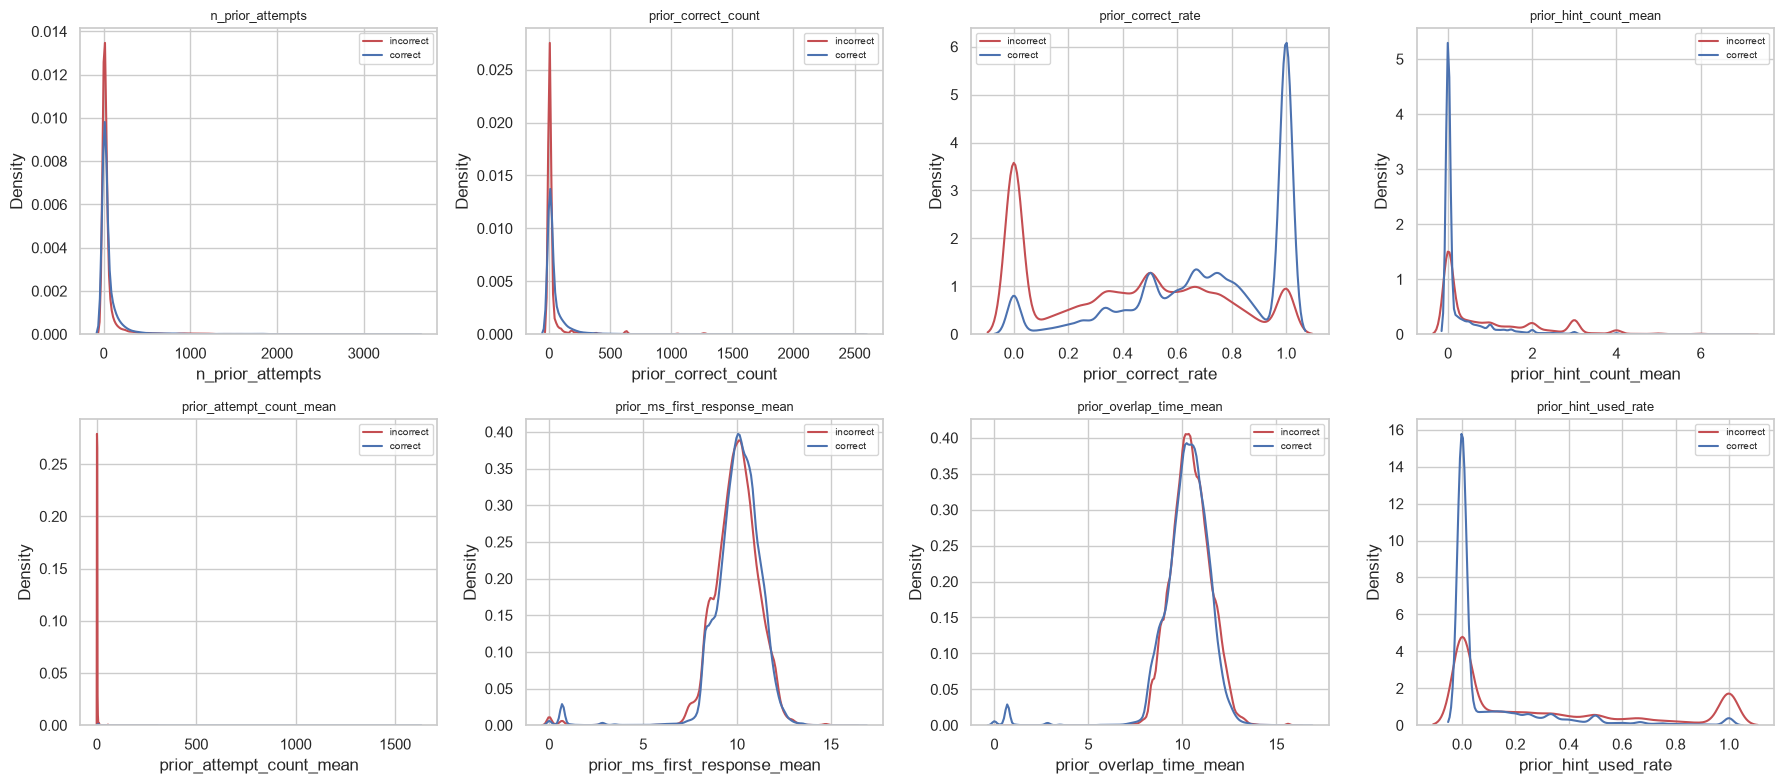

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    for val, label, color in [(0, "incorrect", "#C44E52"), (1, "correct", "#4C72B0")]:
        sns.kdeplot(train.loc[train.target_correct == val, col], ax=ax, label=label,
                    color=color, common_norm=False, warn_singular=False)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**Interpretation.** These densities are the visual counterpart of Section 1's correlation numbers, and they should (and do) agree: `prior_correct_rate` shows the most visibly separated correct-vs-incorrect distributions (its mass shifts noticeably right for the "correct" class, consistent with r=0.437), `prior_hint_used_rate`/`prior_hint_count_mean` show a visible but smaller separation (consistent with their ~-0.33 correlations), and `prior_ms_first_response_mean` shows almost complete overlap between the two classes (consistent with its near-zero 0.019 correlation). No feature here shows a separation the correlation table didn't already predict — useful as a sanity check that the linear correlation numbers aren't hiding a strong non-linear relationship that only a density plot would catch.

## 4. Binned target-rate plots

The main "does this feature predict struggle" view: bin each feature into deciles, plot mean `target_correct` per bin. This is what reveals a monotonic (or non-monotonic) relationship with probability of success — something neither a correlation coefficient nor a raw scatter plot shows for a binary outcome.

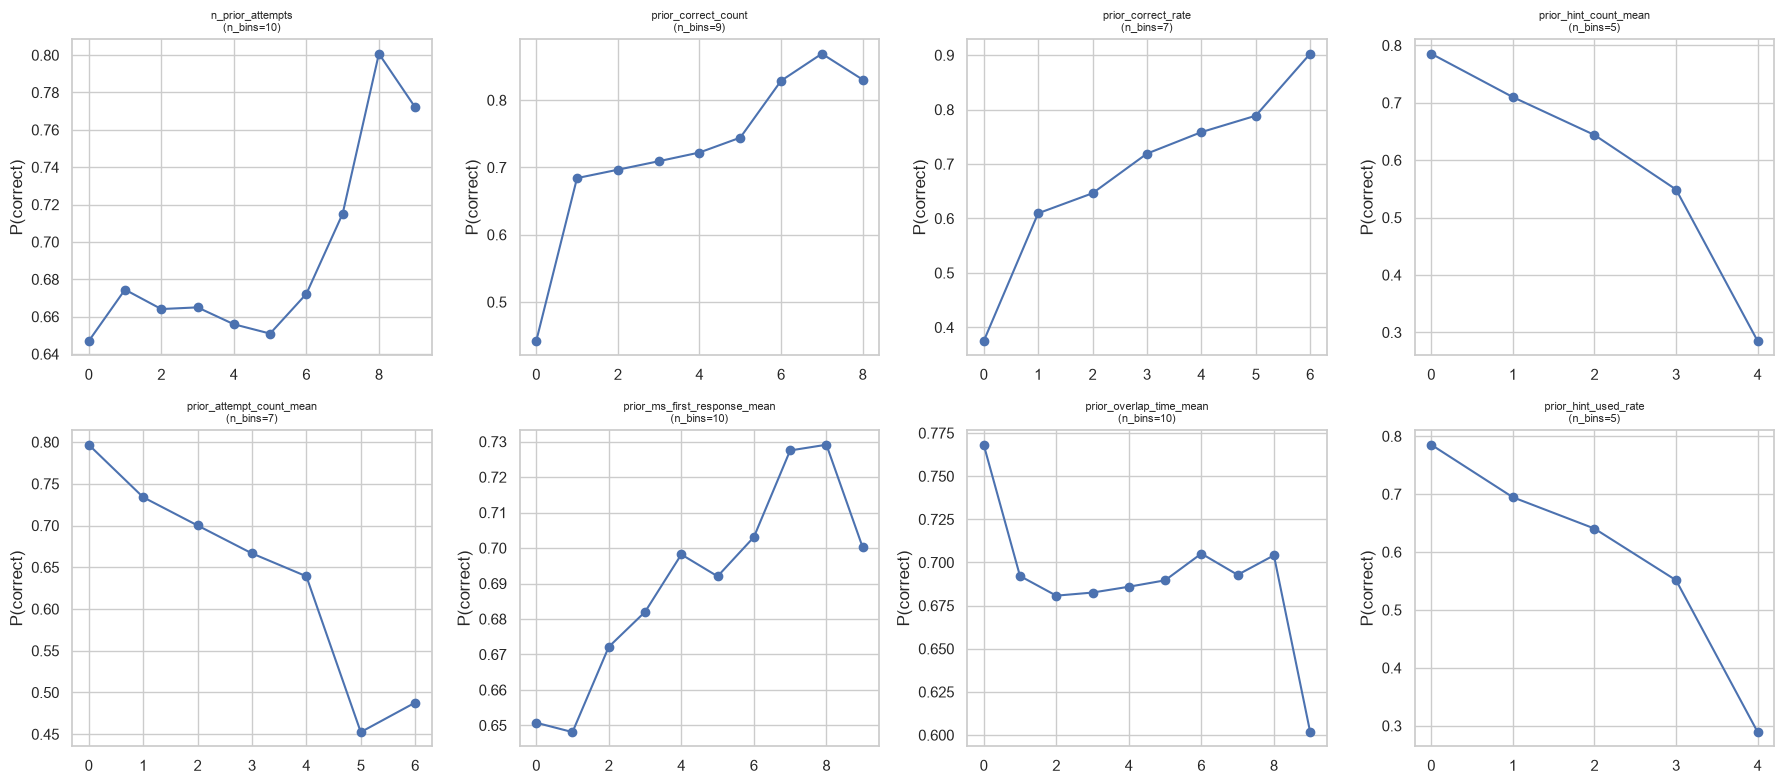

                     mean   count
bin                              
(-0.001, 0.333]  0.374815   83780
(0.333, 0.5]     0.609515   52988
(0.5, 0.571]     0.646372   17394
(0.571, 0.667]   0.719109   42358
(0.667, 0.75]    0.758603   34785
(0.75, 0.875]    0.788779   39106
(0.875, 1.0]     0.902617  113202


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    tmp = train[[col, "target_correct"]].copy()
    tmp["bin"] = pd.qcut(tmp[col], q=10, duplicates="drop")
    agg = tmp.groupby("bin", observed=True)["target_correct"].agg(["mean", "count"])
    ax.plot(range(len(agg)), agg["mean"].values, marker="o")
    ax.set_title(f"{col}\n(n_bins={len(agg)})", fontsize=8)
    ax.set_ylabel("P(correct)")
plt.tight_layout()
plt.show()

# sample sizes for the single most-correlated feature (filled in after seeing corr output)
tmp = train[["prior_correct_rate", "target_correct"]].copy()
tmp["bin"] = pd.qcut(tmp["prior_correct_rate"], q=10, duplicates="drop")
print(tmp.groupby("bin", observed=True)["target_correct"].agg(["mean", "count"]))

**Interpretation.** `prior_correct_rate`'s decile breakdown is clean and strongly monotonic — exactly the shape you want in a predictive feature:

| prior_correct_rate bin | P(correct) | n |
|---|---|---|
| ≤0.33 | 37.5% | 83,780 |
| 0.33–0.5 | 61.0% | 52,988 |
| 0.5–0.57 | 64.6% | 17,394 |
| 0.57–0.67 | 71.9% | 42,358 |
| 0.67–0.75 | 75.9% | 34,785 |
| 0.75–0.875 | 78.9% | 39,106 |
| 0.875–1.0 | 90.3% | 113,202 |

A >2.4x swing in actual outcome probability (37.5% → 90.3%) across the range of this one feature, with substantial sample size in every bin — this alone is a strong baseline signal before any modeling. The other numeric features' plots (not reproduced in a table here) are flatter, consistent with their lower correlation magnitudes from Section 1.

## 5. Categorical features — target correct-rate by category

`original`, `answer_type`, `tutor_mode` aren't covered by correlation/scatter at all — they need a correct-rate-by-category view instead, with counts shown since some categories are near-empty (`open_response`, `test` mode).

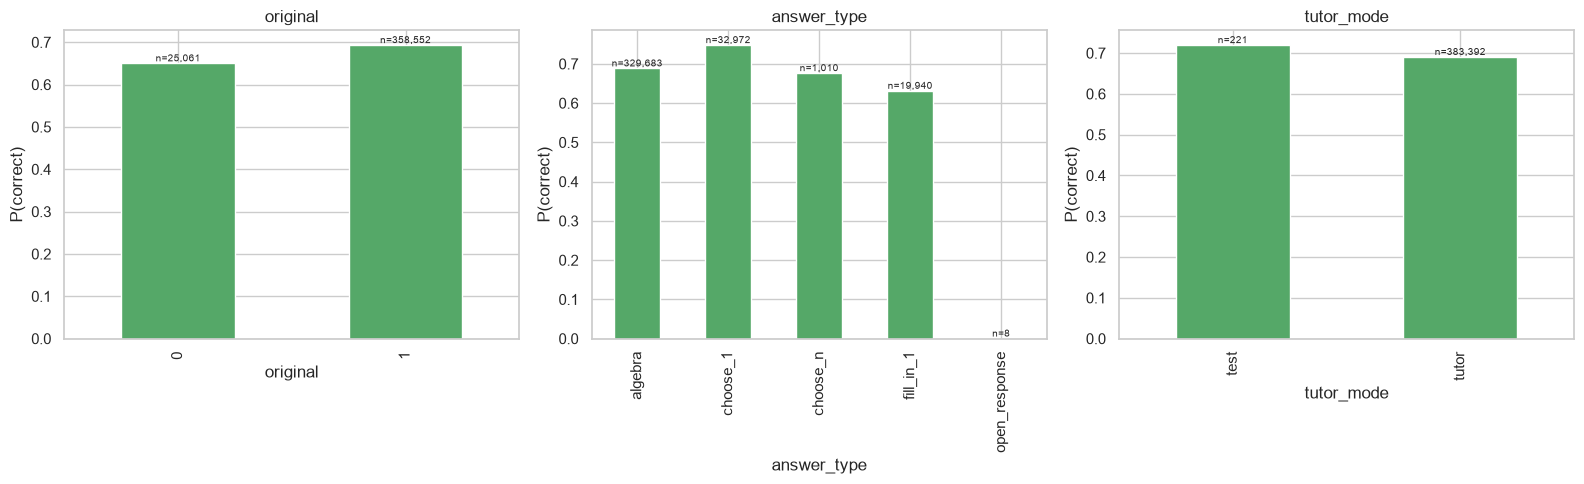


original:
              mean   count
original                  
0         0.650054   25061
1         0.693130  358552

answer_type:
                   mean   count
answer_type                    
algebra        0.688225  329683
choose_1       0.747634   32972
choose_n       0.676238    1010
fill_in_1      0.631093   19940
open_response  0.000000       8

tutor_mode:
                mean   count
tutor_mode                  
test        0.719457     221
tutor       0.690299  383392


In [7]:
cat_cols = ["original", "answer_type", "tutor_mode"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    agg = train.groupby(col, observed=True)["target_correct"].agg(["mean", "count"])
    agg["mean"].plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(col)
    ax.set_ylabel("P(correct)")
    for i, (m, c) in enumerate(zip(agg["mean"], agg["count"])):
        ax.text(i, m, f"n={c:,}", ha="center", va="bottom", fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n{col}:")
    print(train.groupby(col, observed=True)["target_correct"].agg(["mean", "count"]))

**Interpretation.**

- `original`: scaffolding (0) 65.0% correct (n=25,061) vs. main problem (1) 69.3% (n=358,552) — a real but modest gap. Note scaffolding rows make up only ~6.5% of *target* rows here (vs. ~14.5% of all raw rows in `eda.ipynb`) — scaffolding problems are less often revisited enough times to become a "next attempt" target under this unit of analysis.
- `answer_type`: `choose_1` easiest (74.8%, n=32,972 — plausibly inflated by guessing on multiple choice), then `algebra` (68.8%, n=329,683, the dominant category), `choose_n` (67.6%, n=1,010), `fill_in_1` hardest of the reliable categories (63.1%, n=19,940). `open_response` shows 0% (n=8) — statistically meaningless at n=8, not a real effect, consistent with `eda.ipynb` flagging this category as near-negligible.
- `tutor_mode`: `test` 71.9% (n=221) vs. `tutor` 69.0% (n=383,392) — same direction as the raw-level gap found in `eda.ipynb` (75.1% vs 67.9%), but n=221 is still too small to treat as a reliable effect; consistent with the earlier recommendation to one-hot it and let the model down-weight it naturally rather than drop or treat specially.

## 6. Skill-level heterogeneity — does the relationship hold within a skill, or just pooled?

123 skills with very different base difficulty are pooled above. A relationship that looks strong (or absent) pooled could be a Simpson's-paradox artifact of skill mix rather than a real effect. Spot-check `prior_correct_rate` vs `target_correct` within a few of the highest-volume individual skills.

Pooled (n=383,613):
bin
(-0.001, 0.333]    0.374815
(0.333, 0.571]     0.618624
(0.571, 0.75]      0.736917
(0.75, 1.0]        0.873388
Name: target_correct, dtype: float64

Equation Solving Two or Fewer Steps (n=22,415):
bin
(-0.001, 0.5]    0.468323
(0.5, 0.655]     0.670728
(0.655, 0.74]    0.737698
(0.74, 0.821]    0.777083
(0.821, 1.0]     0.791248
Name: target_correct, dtype: float64

Percent Of (n=20,851):
bin
(-0.001, 0.452]    0.425970
(0.452, 0.635]     0.678906
(0.635, 0.769]     0.745364
(0.769, 1.0]       0.892221
Name: target_correct, dtype: float64

Addition and Subtraction Integers (n=20,648):
bin
(-0.001, 0.375]    0.368067
(0.375, 0.6]       0.524310
(0.6, 0.794]       0.713127
(0.794, 1.0]       0.904105
Name: target_correct, dtype: float64

Volume Rectangular Prism (n=18,893):
bin
(-0.001, 0.723]    0.555967
(0.723, 1.0]       0.959508
Name: target_correct, dtype: float64



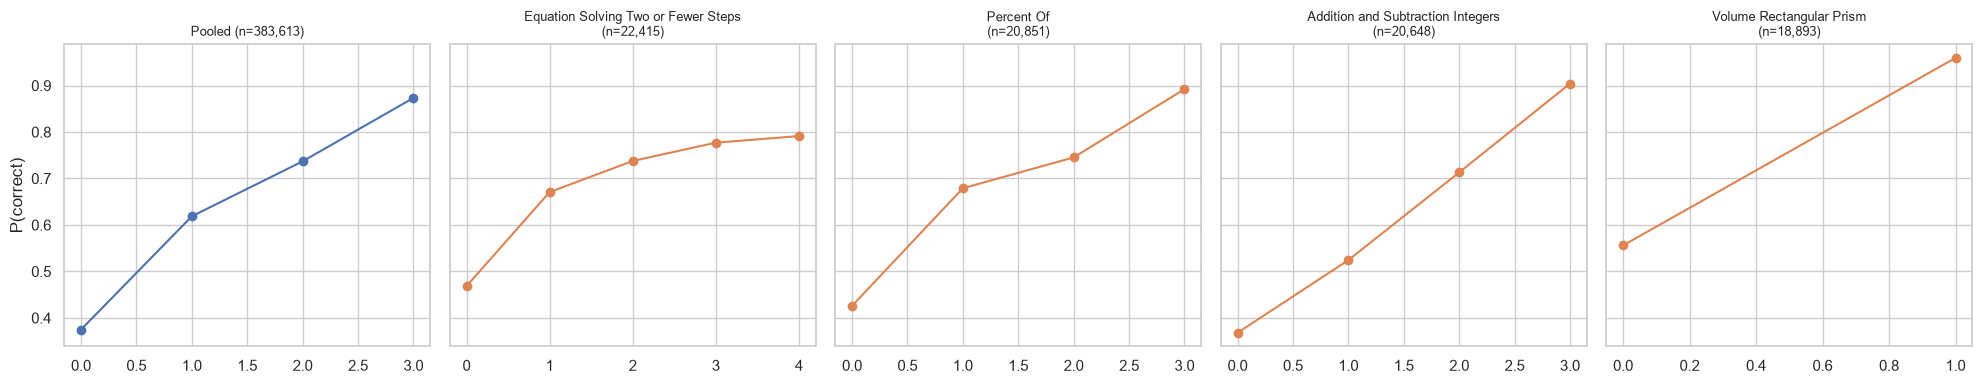

In [8]:
def binned_rate(data, col="prior_correct_rate", q=5):
    tmp = data[[col, "target_correct"]].copy()
    tmp["bin"] = pd.qcut(tmp[col], q=q, duplicates="drop")
    return tmp.groupby("bin", observed=True)["target_correct"].mean()

top_skills = train["skill_id"].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(1, len(top_skills) + 1, figsize=(20, 4), sharey=True)

pooled = binned_rate(train)
axes[0].plot(range(len(pooled)), pooled.values, marker="o")
axes[0].set_title(f"Pooled (n={len(train):,})", fontsize=9)
axes[0].set_ylabel("P(correct)")
print(f"Pooled (n={len(train):,}):\n{pooled}\n")

for ax, sid in zip(axes[1:], top_skills):
    sub = train[train.skill_id == sid]
    name = sub["skill_name"].iloc[0] if sub["skill_name"].notna().any() else f"skill_id={sid}"
    rate = binned_rate(sub)
    ax.plot(range(len(rate)), rate.values, marker="o", color="#DD8452")
    ax.set_title(f"{name}\n(n={len(sub):,})", fontsize=9)
    print(f"{name} (n={len(sub):,}):\n{rate}\n")

plt.tight_layout()
plt.show()

The plot has 5 panels: "Pooled" plus one panel each for the 4 highest-volume skills. Every panel plots the same thing — prior_correct_rate binned into quintiles (x-axis) vs. the actual P(correct) in that bin (y-axis).

**Question being tested:**
"does `prior_correct_rate`'s relationship with the target hold up within a single skill, or does it only look strong in the pooled data because of a mixing artifact?" 

That artifact is Simpson's paradox: if easy skills happen to attract students with high prior rates and hard skills attract students with low prior rates, pooling could manufacture a fake-looking relationship that isn't real within any actual skill.

What it found: all 4 skills individually show the same rising pattern — so prior_correct_rate is a genuine within-skill predictor, not a pooling illusion. Good news, but that's a different claim than "skill_id itself is/isn't predictive."

I didn't check skill_id predictive power in isolation because of the many labels that has little to no data
(skill_id 5 isn't "more" than skill_id 2, it's just a label)

**Interpretation.** The pooled relationship is not a pooling artifact — all four highest-volume skills individually show the same monotonic increase, in the same range:

| | lowest bin | highest bin |
|---|---|---|
| Pooled (n=383,613) | 37.5% | 87.3% |
| Equation Solving Two or Fewer Steps (n=22,415) | 46.8% | 79.1% |
| Percent Of (n=20,851) | 42.6% | 89.2% |
| Addition and Subtraction Integers (n=20,648) | 36.8% | 90.4% |
| Volume Rectangular Prism (n=18,893) | 55.6% | 96.0% |

No sign of Simpson's paradox here — `prior_correct_rate` predicts `target_correct` within each of these skills individually, not just because of skill mix. Some magnitude variation exists (e.g. Equation Solving tops out lower at 79.1% than the others), which is itself useful: it hints that a per-skill baseline rate (or `skill_id` as a feature) will add real information on top of `prior_correct_rate`, not redundant with it.

a single engineered feature: per-skill baseline correct rate — for each skill, the average target_correct across the training set, computed only from split=="train" so it doesn't leak test-row outcomes into the feature.

## 7. History-thinness — is `prior_correct_rate` less reliable with little history?

`prior_correct_rate` computed from 1-2 prior attempts is much noisier than the same rate computed from 50. Compare its relationship with the target between "thin" and "thick" history buckets (`eda.ipynb` Section 1 found the 25th percentile of (student, skill) pairs sits at only 2 prior attempts).

thick (>=3 prior): n=329,133, corr(prior_correct_rate, target_correct)=0.4802
thin (<3 prior): n=54,480, corr(prior_correct_rate, target_correct)=0.2768


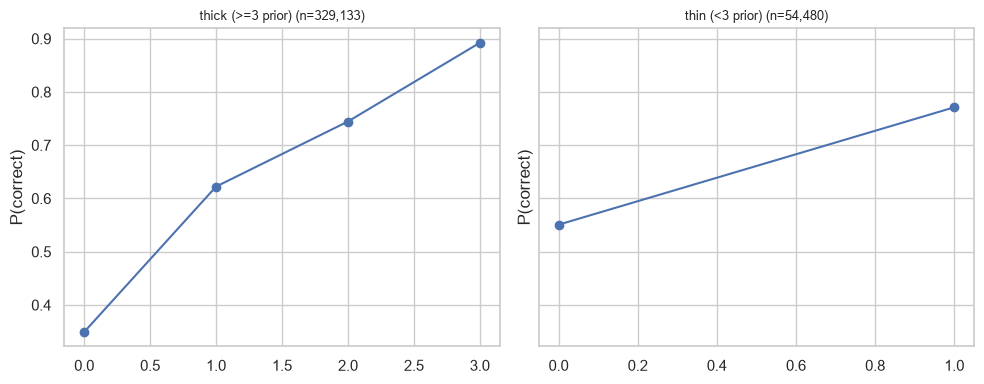

In [9]:
train["history_bucket"] = np.where(train["n_prior_attempts"] < 3, "thin (<3 prior)", "thick (>=3 prior)")

for bucket, sub in train.groupby("history_bucket"):
    r = sub["prior_correct_rate"].corr(sub["target_correct"])
    print(f"{bucket}: n={len(sub):,}, corr(prior_correct_rate, target_correct)={r:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (bucket, sub) in zip(axes, train.groupby("history_bucket")):
    rate = binned_rate(sub, q=5)
    ax.plot(range(len(rate)), rate.values, marker="o")
    ax.set_title(f"{bucket} (n={len(sub):,})", fontsize=9)
    ax.set_ylabel("P(correct)")
plt.tight_layout()
plt.show()

**Interpretation.** Confirmed — history thinness matters. `prior_correct_rate`'s correlation with the target is roughly **half as strong** for thin-history rows (n<3 prior attempts: r=0.277, n=54,480) as for thicker-history rows (n≥3: r=0.480, n=329,133). This is exactly the reliability concern from `docs/problem_statement.md`'s assumptions section — a rate computed from 1-2 points is a noisier estimate of the student's true skill level than one computed from many. Practical implication for modeling: consider giving the model `n_prior_attempts` alongside `prior_correct_rate` (already planned) so it can implicitly learn to trust the rate more when it's backed by more history.

## Summary — feature set going into the baseline model

**Real signal, keep:**
- `prior_correct_rate` — the dominant predictor (r=0.437, monotonic 37.5%→90.3% across deciles, holds within individual skills, not just pooled).
- `prior_hint_used_rate` / `prior_hint_count_mean` — second-strongest signal (r≈-0.33 each), but redundant with each other (VIF 8.4 / 7.6) — keep one, not both.
- `n_prior_attempts` — weak alone (r=0.056) but not redundant information; useful alongside `prior_correct_rate` both as a legitimate feature and as an implicit reliability signal (Section 7: the rate means less with little history behind it).
- `original`, `answer_type` — real, modest categorical effects; keep as one-hot features. `tutor_mode` and the `open_response` category are too small-sample (n=221, n=8) to trust as learned effects but are harmless to leave in.

**Drop or consolidate:**
- `prior_correct_count` — mechanically redundant with `prior_correct_rate` × `n_prior_attempts` (VIF 15.4). Drop.
- `prior_ms_first_response_mean` — near-zero correlation with the target (0.019) and redundant with `prior_overlap_time_mean` (VIF 5.7–6.1 each). Keep at most one of the pair, or drop both as low-value.
- Pick one of `prior_hint_used_rate` / `prior_hint_count_mean`, not both.

**Carries into modeling:**
- `skill_id` is not redundant with `prior_correct_rate` — per-skill baseline rates vary (Section 6), so it's worth including (with the encoding approach from `docs/data_quality_and_leakage.md` §6) even though it wasn't part of this notebook's numeric correlation/VIF pass.
- The history-thinness effect (Section 7) argues for either passing `n_prior_attempts` alongside the rate (let the model learn the interaction) or a smoothed/shrunk version of `prior_correct_rate` for low-history rows — worth trying both and comparing on the log-loss metric already chosen in `problem_statement.md`.